# Movie Dataset Analysis

In [2]:
# Data manipulation and numerical computations
import pandas as pd
import numpy as np

# Visualization libraries for EDA
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

In [ ]:
# Load the movie dataset from CSV file
df = pd.read_csv('../Data/movies_dataset.csv')

## Initial Dataset Inspection

In [16]:
# Overview of dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  object 
 2   Genre                 999999 non-null  object 
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  object 
 5   Country               999999 non-null  object 
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  

In [17]:
# Display the first 5 rows of the dataset to get an initial overview of its structure and values
df.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [18]:
# Display the last 5 rows of the dataset to check the ending entries and verify data consistency
df.tail()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
999994,999995,He anyone,Action,2011,14-09-2011,China,648176.38,1075869.51,2624306.41,170212.67,614079.92,4.8,58,12664,586,Nathan Bolton,Stephanie Moore
999995,999996,Single yourself sister collection,Horror,1982,27-08-1982,USA,657167.15,1046949.86,2164587.12,119899.27,564950.72,7.3,83,622,2327,David Lee,Tracy Klein
999996,999997,Old economic,Documentary,1993,12-02-1993,USA,29914685.15,30619499.73,57774787.73,6331667.63,18136941.88,4.1,32,100,1394,Jeremy Davis,Lynn Pierce
999997,999998,My itself and leave,Horror,2013,11-11-2013,India,1382498.55,3168114.87,5567631.38,438945.44,1703606.02,4.3,23,2337,105,Melanie Olson,Melissa Mcgee
999998,999999,Congress federal policy,Drama,1995,09-08-1995,USA,7655641.81,18626549.48,34908325.31,4342391.46,10764341.98,6.6,60,24528,872,Albert Phillips,Samantha Sanders


In [19]:
# Get dataset dimensions (rows, columns)
df.shape

(999999, 17)

In [20]:
# Summary statistics of numerical columns
df.describe()


,MovieID,ReleaseYear,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,999999.000000,999999.000000,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000,999999.000000,999999.000000,999999.000000
mean,500000.000000,1998.001220,9.802824e+06,1.496163e+07,2.720625e+07,2.992745e+06,7.483442e+06,6.494788,64.776426,9137.184011,2031.880340
std,288674.990257,19.260863,2.249421e+07,3.879403e+07,6.954294e+07,8.132438e+06,1.955337e+07,1.485606,17.592474,24922.362780,8433.380602
min,1.000000,1950.000000,1.000000e+05,4.002547e+04,1.000000e+05,4.050470e+03,1.650742e+04,1.000000,0.000000,100.000000,50.000000
25%,250000.500000,1984.000000,1.190511e+06,1.489805e+06,2.762370e+06,2.790262e+05,7.383145e+05,5.500000,53.000000,1083.000000,119.000000
50%,500000.000000,2001.000000,3.265790e+06,4.388876e+06,8.090223e+06,8.387221e+05,2.179436e+06,6.500000,65.000000,2983.000000,405.000000
75%,749999.500000,2014.000000,9.002791e+06,1.287606e+07,2.355245e+07,2.510360e+06,6.415143e+06,7.500000,77.000000,8192.000000,1360.000000
max,999999.000000,2025.000000,3.000000e+08,1.018198e+09,1.499497e+09,2.957511e+08,5.795551e+08,10.000000,100.000000,1000000.000000,500000.000000


In [21]:
# Count missing values in each column
df.isna().sum()

MovieID                 0
Title                   0
Genre                   0
ReleaseYear             0
ReleaseDate             0
Country                 0
BudgetUSD               0
US_BoxOfficeUSD         0
Global_BoxOfficeUSD     0
Opening_Day_SalesUSD    0
One_Week_SalesUSD       0
IMDbRating              0
RottenTomatoesScore     0
NumVotesIMDb            0
NumVotesRT              0
Director                0
LeadActor               0
dtype: int64

In [22]:
# Check for duplicate rows in the dataset
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
999994    False
999995    False
999996    False
999997    False
999998    False
Length: 999999, dtype: bool

In [23]:
# List all column names
df.columns

Index(['MovieID', 'Title', 'Genre', 'ReleaseYear', 'ReleaseDate', 'Country',
       'BudgetUSD', 'US_BoxOfficeUSD', 'Global_BoxOfficeUSD',
       'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
       'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT', 'Director',
       'LeadActor'],
      dtype='object')

## Exploratory Data Analysis

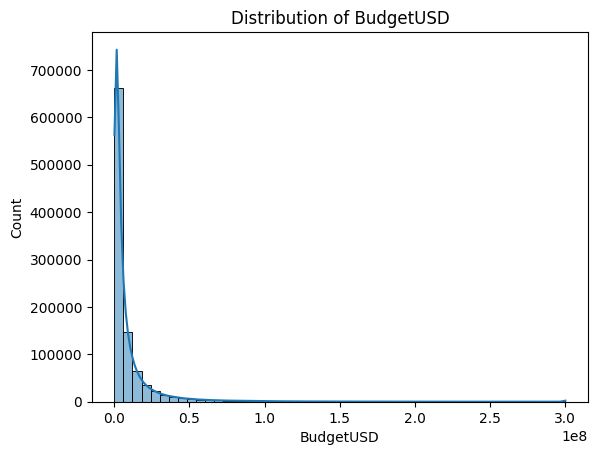

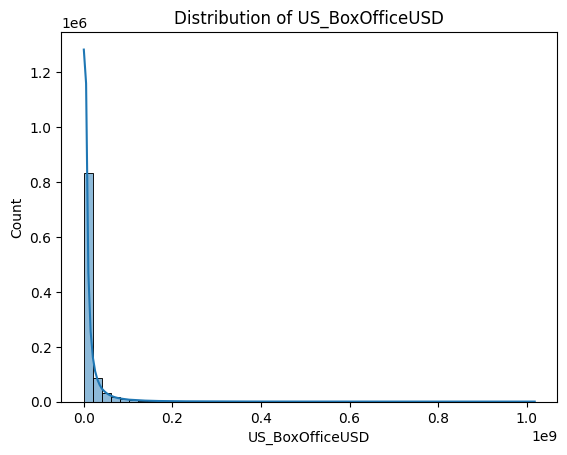

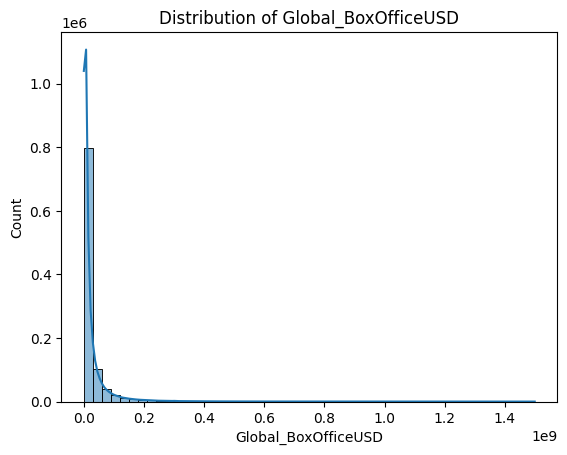

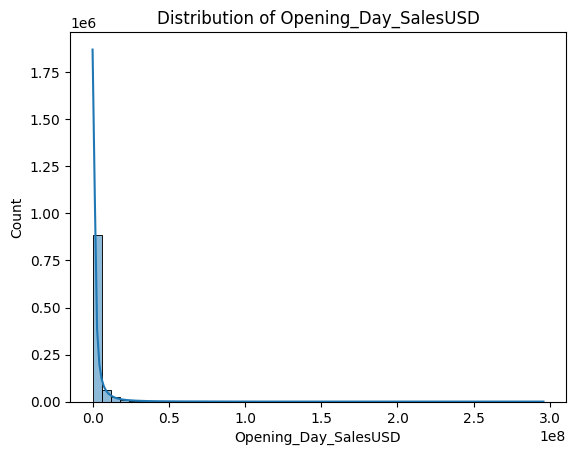

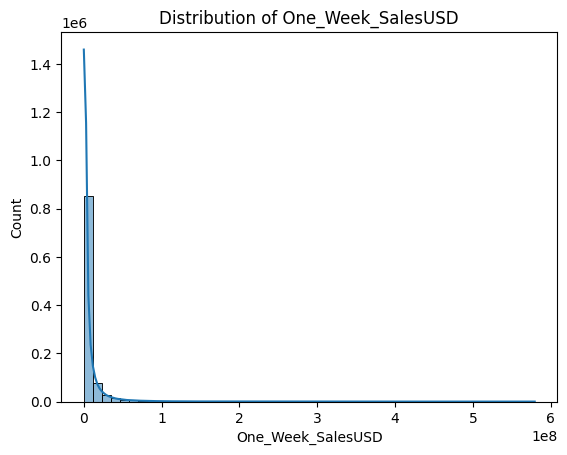

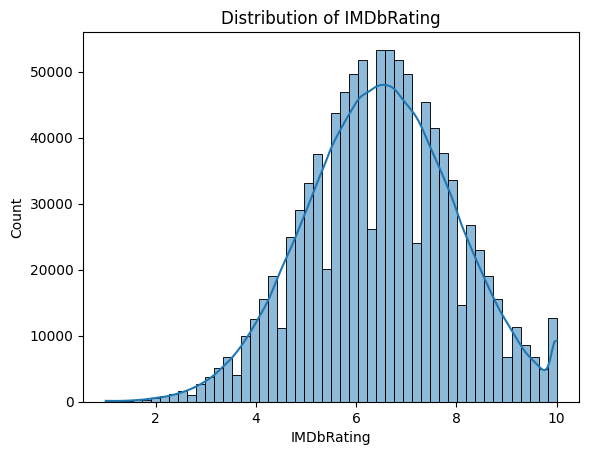

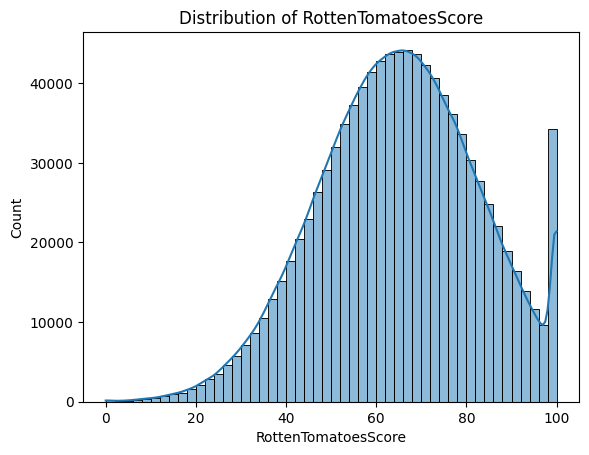

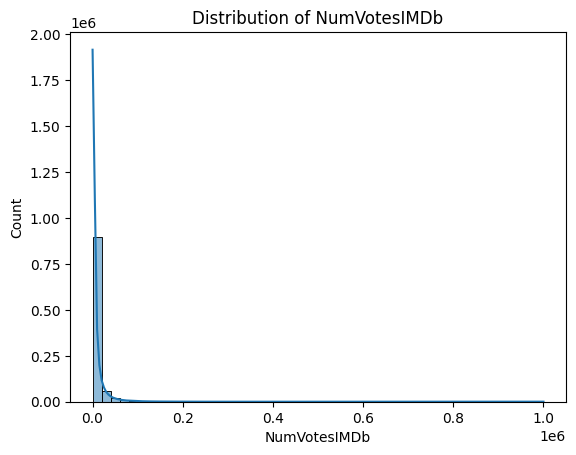

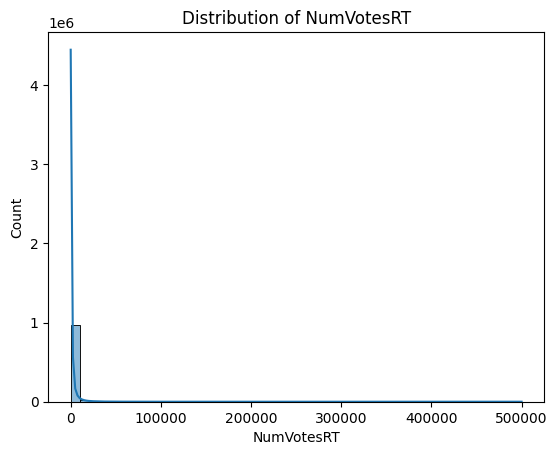

In [24]:
# Plot distributions of numeric columns with histograms and KDE
numeric_cols = ['BudgetUSD','US_BoxOfficeUSD','Global_BoxOfficeUSD',
                'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'IMDbRating',
                'RottenTomatoesScore', 'NumVotesIMDb', 'NumVotesRT']

for col in numeric_cols:
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


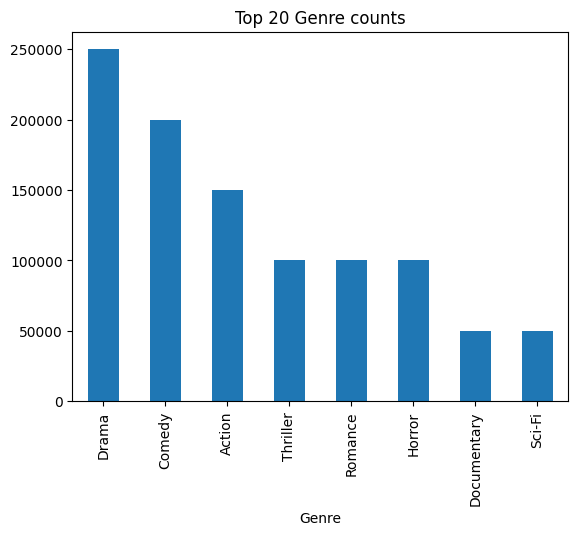

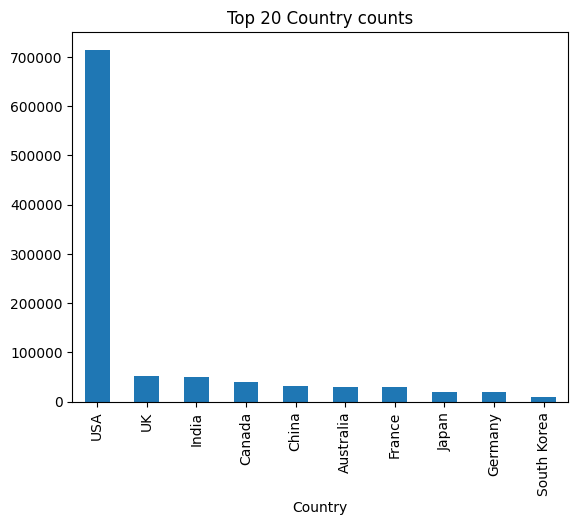

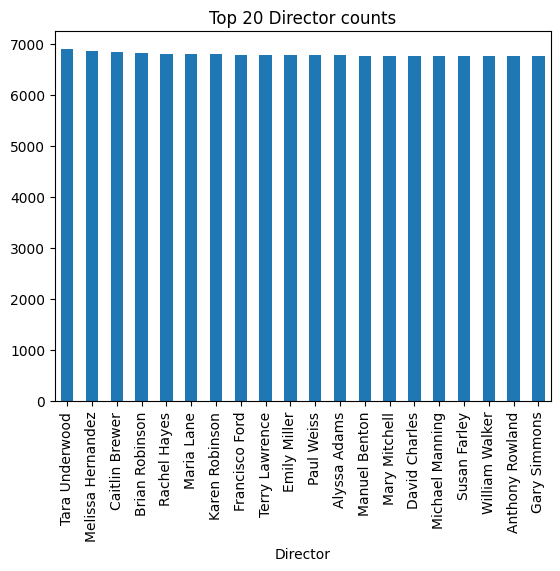

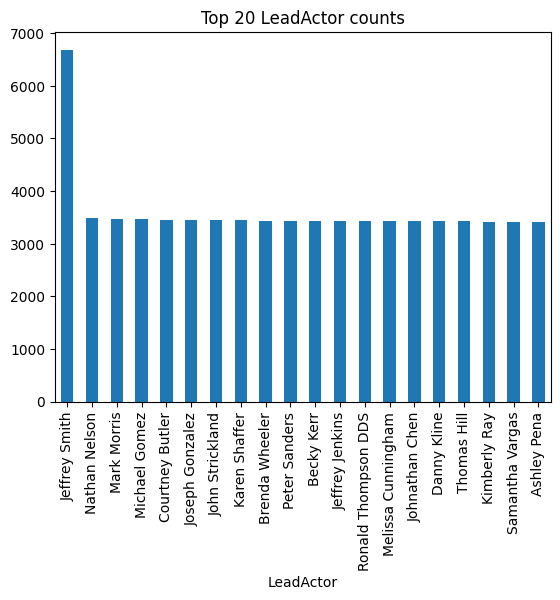

In [25]:
# Plot top 20 counts for categorical columns
categorical_cols = ['Genre','Country','Director','LeadActor']

for col in categorical_cols:
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"Top 20 {col} counts")
    plt.show()


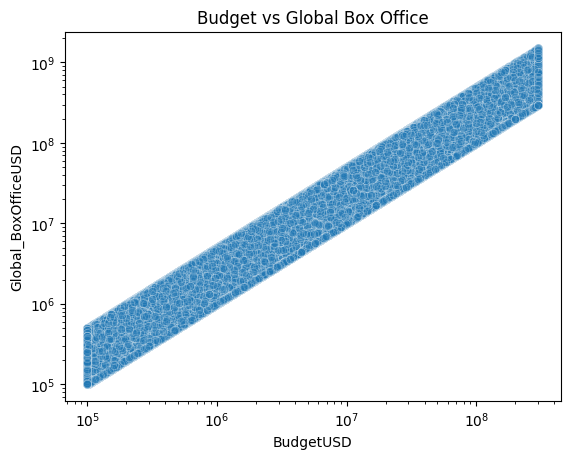

In [26]:
# Scatter plot of Budget vs Global Box Office (log scale)
sns.scatterplot(data=df, x="BudgetUSD", y="Global_BoxOfficeUSD", alpha=0.3)
plt.title("Budget vs Global Box Office")
plt.xscale("log")
plt.yscale("log")
plt.show()


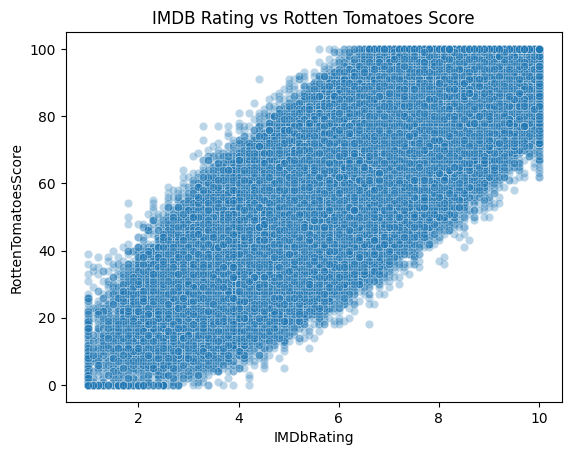

In [27]:
# Scatter plot of IMDb Rating vs Rotten Tomatoes Score
sns.scatterplot(data=df, x='IMDbRating', y='RottenTomatoesScore', alpha=0.3)
plt.title("IMDB Rating vs Rotten Tomatoes Score")
plt.show()

In [30]:
# Compute yearly averages of key metrics by Genre
genre_year_status = df.groupby(["Genre","ReleaseYear"]).agg({
    "Global_BoxOfficeUSD": "mean",
    "BudgetUSD": "mean",
    "IMDbRating": "mean",
    "RottenTomatoesScore": "mean"
})
genre_year_status

Global_BoxOfficeUSD     BudgetUSD  IMDbRating  \
Genre    ReleaseYear                                                  
Action   1950                2.897931e+07  1.011213e+07    6.361671   
         1951                2.896091e+07  1.027247e+07    6.546575   
         1952                2.789712e+07  9.683596e+06    6.487152   
         1953                2.762857e+07  9.471222e+06    6.387726   
         1954                3.244328e+07  1.054447e+07    6.511553   
...                                   ...           ...         ...   
Thriller 2021                2.859975e+07  1.012603e+07    6.477995   
         2022                2.670292e+07  9.452524e+06    6.466554   
         2023                2.694591e+07  9.877671e+06    6.527363   
         2024                2.576942e+07  9.764218e+06    6.490901   
         2025                2.595418e+07  9.668806e+06    6.535658   

                      RottenTomatoesScore  
Genre    ReleaseYear                       
Action   1950                   63.564841  
         1951                   65.671233  
         1952                   64.175589  
         1953                   63.466801  
         1954                   64.107955  
...                                   ...  
Thriller 2021                   64.689465  
         2022                   64.122777  
         2023                   65.149914  
         2024                   64.358491  
         2025                   65.022831  

[608 rows x 4 columns]

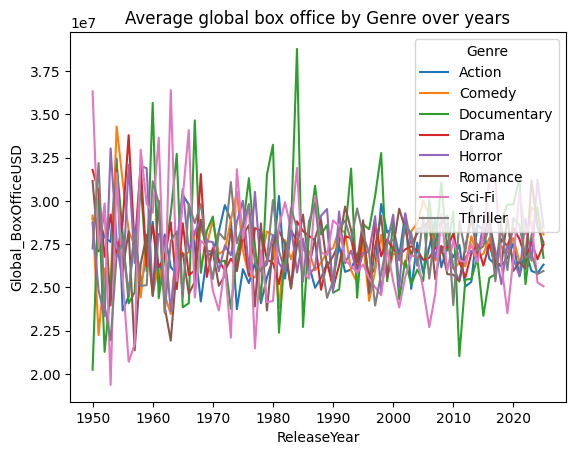

In [ ]:
# Line plot of average Global Box Office over years by Genre
sns.lineplot(data=genre_year_status, x="ReleaseYear", y="Global_BoxOfficeUSD", hue="Genre")
plt.title("Average global box office by Genre over years")
plt.show()


## Conclusion

From the exploratory data analysis, we observe that:  
- The dataset is mostly complete with few missing values and minimal duplicates.  
- Numeric features like budget and box office revenues show skewed distributions, suggesting the presence of outliers and high variability.  
- Categorical features such as Genre, Country, Director, and LeadActor are dominated by a few frequent categories.  
- There is a positive correlation between Budget and Global Box Office, indicating higher-budget movies tend to earn more.  
- IMDb Ratings and Rotten Tomatoes Scores are moderately correlated, reflecting some alignment between audience and critic ratings.  
- Over the years, certain genres consistently outperform others in global box office revenue, highlighting trends in audience preferences.